# Сравнение моделей (макро уровень)

Room popularity, Edge-load. Реальные треки vs симулированные (Unity).

**Вход:** DXF с планом и зонами, папка CSV с реальными треками, слой Simulation.

---

### Параметры симуляции (Unity)

- 51 агент, интервал старта 2–6 сек, от 3 до 50 точек на агента
- Ожидание у картины: 1–10 сек, Loop: выключен, избегание толпы


In [144]:
import sys
from pathlib import Path

# Чтобы импорт room_popularity работал при запуске из model_search или из корня репозитория
for d in [Path.cwd(), Path.cwd() / "model_search"]:
    if (d / "room_popularity.py").exists() and str(d) not in sys.path:
        sys.path.insert(0, str(d))
        break

# DXF: в этой же папке или model_search/ при запуске из корня
PATH_DXF = str(Path("model_search") / "Floor_0.dxf") if (Path.cwd() / "model_search" / "Floor_0.dxf").exists() else "Floor_0.dxf"
PATH_TRAJECTORIES_CSV = "C://Users/malko/Desktop/Diploma/Term/bird-dataset-main/bird-dataset-main/data/normalized_trajectories"
LAYER_FLOOR_PLAN = "Floor_plan"
LAYER_AREA = "Area"
LAYER_SIMULATION = "Simulation"  # треки из симуляции Unity

In [145]:
%pip install -q ezdxf pandas shapely matplotlib scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Треки: реальные и симулированные (с планом этажа)

Ниже — две визуализации: реальные треки из датасета и симулированные треки из Unity. Оба наложены на план этажа из DXF.

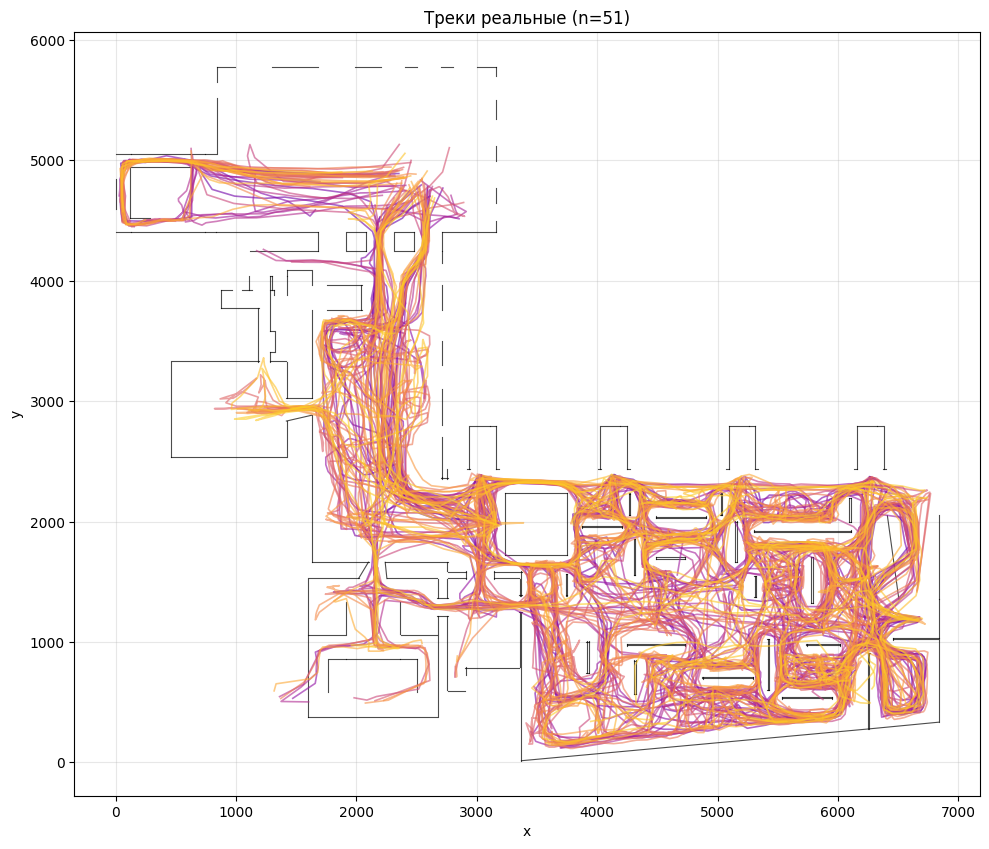

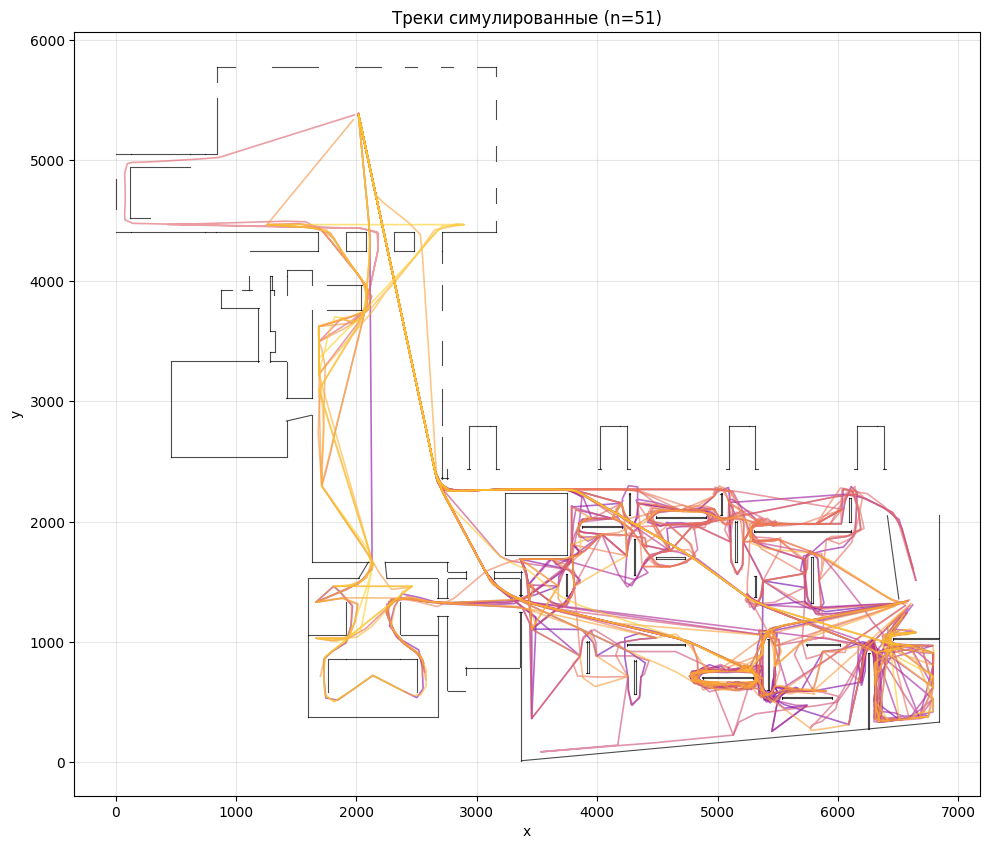

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from room_popularity import load_trajectories_from_csv, parse_trajectories_from_dxf

def _parse_floor_plan(path_dxf, layer):
    import ezdxf
    doc = ezdxf.readfile(str(Path(path_dxf).resolve()))
    msp = doc.modelspace()
    segs = []
    for e in msp.query("LWPOLYLINE"):
        if getattr(e.dxf, "layer", "") != layer:
            continue
        try:
            pts = list(e.get_points("xy"))
        except Exception:
            continue
        for i in range(len(pts) - 1):
            segs.append((float(pts[i][0]), float(pts[i][1]), float(pts[i+1][0]), float(pts[i+1][1])))
    for e in msp.query("LINE"):
        if getattr(e.dxf, "layer", "") != layer:
            continue
        try:
            s, en = e.dxf.start, e.dxf.end
            segs.append((float(s.x), float(s.y), float(en.x), float(en.y)))
        except Exception:
            continue
    return segs

plan_segments = _parse_floor_plan(PATH_DXF, LAYER_FLOOR_PLAN)
traj_real = load_trajectories_from_csv(PATH_TRAJECTORIES_CSV, floor_number=0)
traj_sim = parse_trajectories_from_dxf(PATH_DXF, LAYER_SIMULATION)

def plot_tracks_with_plan(trajectories, title):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect("equal")
    for (x1, y1, x2, y2) in plan_segments:
        ax.plot([x1, x2], [y1, y2], "k-", linewidth=0.8, alpha=0.7)
    JUMP_THRESHOLD = 500
    colors = plt.cm.plasma(np.linspace(0.2, 0.9, max(len(trajectories), 1)))
    for i, points in enumerate(trajectories):
        if len(points) < 2:
            continue
        xs = np.array([p[0] for p in points])
        ys = np.array([p[1] for p in points])
        dist = np.sqrt(np.diff(xs)**2 + np.diff(ys)**2)
        breaks = np.concatenate([[0], np.where(dist > JUMP_THRESHOLD)[0] + 1, [len(points)]])
        for j in range(len(breaks) - 1):
            start, end = int(breaks[j]), int(breaks[j + 1])
            if end - start >= 2:
                ax.plot(xs[start:end], ys[start:end], "-", color=colors[i % len(colors)], alpha=0.6, linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_tracks_with_plan(traj_real, f"Треки реальные (n={len(traj_real)})")
plot_tracks_with_plan(traj_sim, f"Треки симулированные (n={len(traj_sim)})")

## Room popularity ranking (real)

Подсчёт: сколько уникальных агентов посетило каждую зону. Цепочка — от наименее к наиболее популярной (zone | n_agents_visited | rank).

In [147]:
import importlib
import room_popularity
importlib.reload(room_popularity)
from room_popularity import compute_room_popularity_ranking, load_trajectories_from_csv

# Room popularity (real) — треки из CSV
traj_real = load_trajectories_from_csv(PATH_TRAJECTORIES_CSV, floor_number=0)
df_real, chain_real, n_traj_real = compute_room_popularity_ranking(
    PATH_DXF, LAYER_AREA, trajectories=traj_real
)
print("Room popularity (real), n_trajectories:", n_traj_real)
display(df_real)
print("Цепочка:", ", ".join(map(str, chain_real)))

Room popularity (real), n_trajectories: 51


,zone,n_agents_visited,rank
0,4,12,1
1,2,20,2
2,6,31,3
3,14,33,4
4,11,41,5
5,1,42,6
6,12,43,7
7,9,45,8
8,8,47,9
9,15,47,10


Цепочка: 4, 2, 6, 14, 11, 1, 12, 9, 8, 15, 7, 10, 13, 0, 3, 5


In [148]:
from room_popularity import save_ranking

out_csv, out_json = save_ranking(
    df_real, chain_real, PATH_DXF, n_traj_real,
    layer_floor_plan=LAYER_FLOOR_PLAN,
    layer_area=LAYER_AREA,
    layer_trajectories="csv",
)
print(f"Сохранено: {out_csv}, {out_json}")

Сохранено: C:\Users\malko\Desktop\Diploma\Term\bird-dataset-main\model_search\room_popularity_ranking.csv, C:\Users\malko\Desktop\Diploma\Term\bird-dataset-main\model_search\room_popularity_ranking.json


## Room popularity ranking (simulated)

То же для симулированных треков (слой Simulation). Сравнение с real показывает, насколько симуляция повторяет паттерн популярности зон.

In [149]:
df_sim, chain_sim, n_traj_sim = compute_room_popularity_ranking(
    PATH_DXF, LAYER_AREA, LAYER_SIMULATION, LAYER_FLOOR_PLAN
)
if n_traj_sim == 0:
    print("Слой Simulation пуст или отсутствует.")
else:
    print("Room popularity (simulated), n_trajectories:", n_traj_sim)
    display(df_sim)
    print("Цепочка:", ", ".join(map(str, chain_sim)))

Room popularity (simulated), n_trajectories: 51


,zone,n_agents_visited,rank
0,1,1,1
1,12,7,2
2,2,12,3
3,14,14,4
4,9,17,5
5,11,18,6
6,15,20,7
7,6,29,8
8,8,29,9
9,7,34,10


Цепочка: 1, 12, 2, 14, 9, 11, 15, 6, 8, 7, 13, 10, 0, 3, 5


## Сравнение room popularity

Scatter plot (n_agents real vs sim), базовая статистика (корреляция Пирсона и Спирмена), slopegraph (соединяет одинаковые зоны между ранжированиями real и sim).

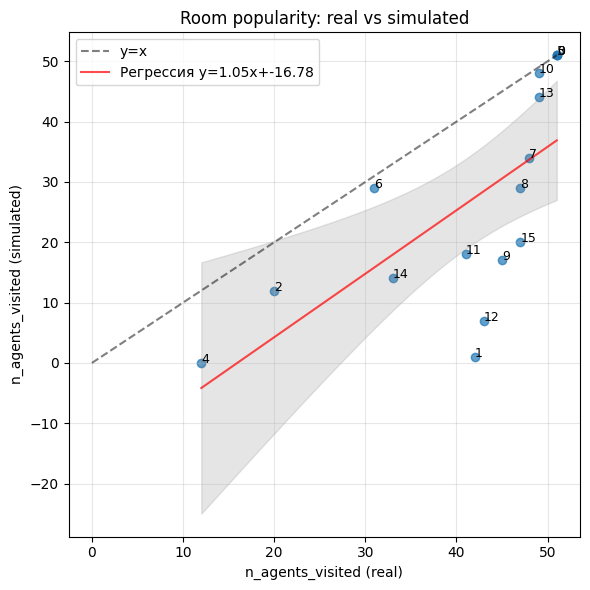

n_real: mean=43.2, std=8.9
n_sim:  mean=28.4, std=17.3
Корреляция Пирсона (n_agents): r=0.600, p=0.0179
Корреляция Спирмена (rank):     r=0.843, p=0.0001


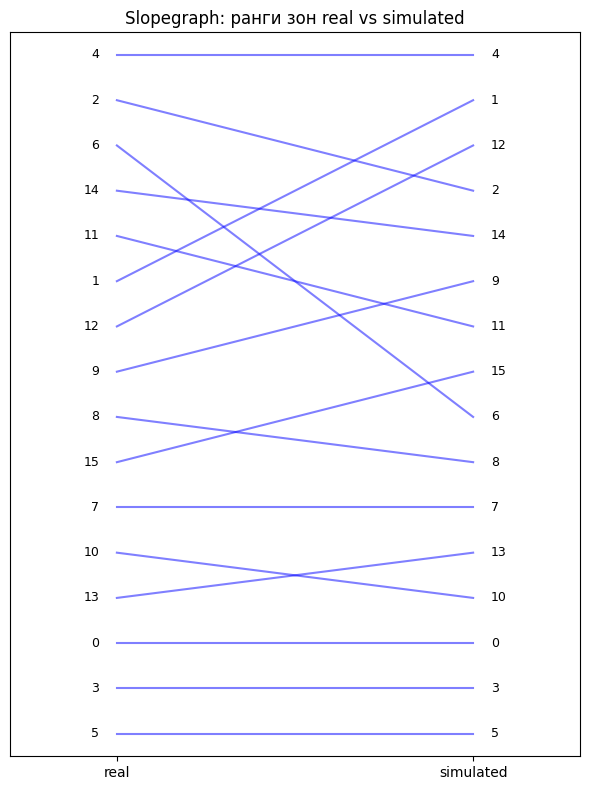

In [150]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr, t as t_dist

if n_traj_sim == 0 or len(df_sim) == 0:
    print("Нет симулированных данных для сравнения.")
else:
    compare_df = df_real.rename(columns={"rank": "rank_real", "n_agents_visited": "n_real"})
    sim_df = df_sim.rename(columns={"rank": "rank_sim", "n_agents_visited": "n_sim"})
    compare_df = compare_df.merge(sim_df[["zone", "rank_sim", "n_sim"]], on="zone", how="outer")
    compare_df = compare_df.fillna(0).astype({"rank_sim": int, "n_sim": int})
    valid = compare_df[(compare_df["n_real"] > 0) | (compare_df["n_sim"] > 0)]

    # Scatter: n_real vs n_sim
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(valid["n_real"], valid["n_sim"], alpha=0.7)
    for _, r in valid.iterrows():
        ax.annotate(str(int(r["zone"])), (r["n_real"], r["n_sim"]), fontsize=9)
    mx = max(valid["n_real"].max(), valid["n_sim"].max())
    ax.plot([0, mx], [0, mx], "k--", alpha=0.5, label="y=x")
    b, a = np.polyfit(valid["n_real"], valid["n_sim"], 1)
    x_line = np.linspace(valid["n_real"].min(), valid["n_real"].max(), 100)
    y_line = a + b * x_line
    if len(valid) >= 3:
        x_vals, y_vals = valid["n_real"].values, valid["n_sim"].values
        n = len(x_vals)
        y_pred = a + b * x_vals
        mse = np.sum((y_vals - y_pred)**2) / (n - 2)
        x_mean = np.mean(x_vals)
        ss_x = np.sum((x_vals - x_mean)**2)
        se = np.sqrt(mse * (1/n + (x_line - x_mean)**2 / ss_x))
        t_val = t_dist.ppf(0.975, n - 2)
        ax.fill_between(x_line, y_line - t_val * se, y_line + t_val * se, alpha=0.2, color="gray")
    ax.plot(x_line, y_line, "r-", alpha=0.7, label=f"Регрессия y={b:.2f}x+{a:.2f}")
    ax.set_xlabel("n_agents_visited (real)")
    ax.set_ylabel("n_agents_visited (simulated)")
    ax.set_title("Room popularity: real vs simulated")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Статистика
    both = compare_df[(compare_df["n_real"] > 0) & (compare_df["n_sim"] > 0)]
    if len(both) >= 2:
        r_pearson, p_pearson = pearsonr(both["n_real"], both["n_sim"])
        r_spearman, p_spearman = spearmanr(both["rank_real"], both["rank_sim"])
        print(f"n_real: mean={both['n_real'].mean():.1f}, std={both['n_real'].std():.1f}")
        print(f"n_sim:  mean={both['n_sim'].mean():.1f}, std={both['n_sim'].std():.1f}")
        print(f"Корреляция Пирсона (n_agents): r={r_pearson:.3f}, p={p_pearson:.4f}")
        print(f"Корреляция Спирмена (rank):     r={r_spearman:.3f}, p={p_spearman:.4f}")

    # Slopegraph: зоны слева по rank_real, справа по rank_sim
    df_left = compare_df.sort_values("rank_real").reset_index(drop=True)
    rank_to_pos_right = dict(zip(df_left.sort_values("rank_sim")["zone"], range(len(df_left))))
    fig, ax = plt.subplots(figsize=(6, 8))
    n = len(df_left)
    for i, row in df_left.iterrows():
        z = row["zone"]
        y_right = rank_to_pos_right.get(z, i)
        ax.plot([0, 1], [i, y_right], "b-", alpha=0.5)
        ax.text(-0.05, i, f"{int(z)}", ha="right", va="center", fontsize=9)
        ax.text(1.05, y_right, f"{int(z)}", ha="left", va="center", fontsize=9)
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["real", "simulated"])
    ax.set_yticks([])
    ax.set_title("Slopegraph: ранги зон real vs simulated")
    plt.tight_layout()
    plt.show()

## Edge-load (real)

Популярность переходов между зонами: для каждой пары (from_zone, to_zone) — доля переходов от общего числа (dependency_pct). Показывает, какие проходы чаще используют агенты.

Edge-load (real), total transitions: 1197
n_edges (уникальных переходов): 65
dependency_pct: min=0.08, max=4.34, mean=1.54, median=1.17, std=1.24
count: min=1, max=52, mean=18.42, median=14.00, std=14.82


,from_zone,to_zone,count,dependency,dependency_pct
0,0,1,14,0.011696,1.17
1,0,5,42,0.035088,3.51
2,1,0,28,0.023392,2.34
3,1,2,1,0.000835,0.08
4,1,5,2,0.001671,0.17
...,...,...,...,...,...
60,14,15,2,0.001671,0.17
61,15,7,25,0.020886,2.09
62,15,11,1,0.000835,0.08
63,15,13,41,0.034252,3.43


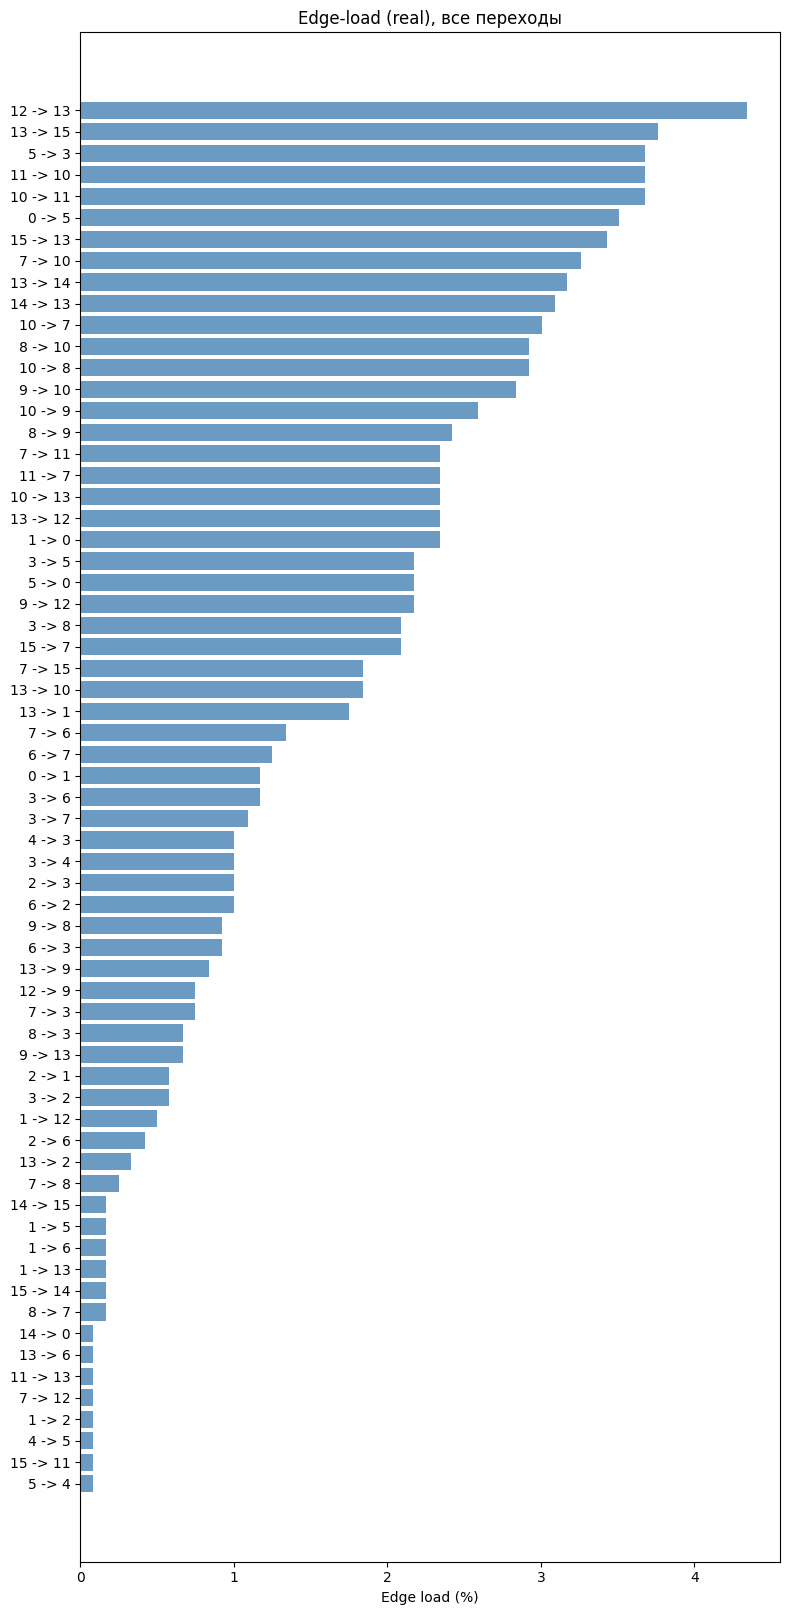

In [151]:
import importlib
import room_popularity
importlib.reload(room_popularity)
from room_popularity import parse_zones_from_dxf, load_trajectories_from_csv, compute_transition_matrix
import matplotlib.pyplot as plt

polygons_with_zone, zone_labels = parse_zones_from_dxf(PATH_DXF, LAYER_AREA)
traj_real = load_trajectories_from_csv(PATH_TRAJECTORIES_CSV, floor_number=0)
df_trans_real, total_real = compute_transition_matrix(polygons_with_zone, zone_labels, traj_real)
print("Edge-load (real), total transitions:", total_real)
print("n_edges (уникальных переходов):", len(df_trans_real))
print("dependency_pct: min={:.2f}, max={:.2f}, mean={:.2f}, median={:.2f}, std={:.2f}".format(
    df_trans_real["dependency_pct"].min(), df_trans_real["dependency_pct"].max(),
    df_trans_real["dependency_pct"].mean(), df_trans_real["dependency_pct"].median(),
    df_trans_real["dependency_pct"].std()))
print("count: min={}, max={}, mean={:.2f}, median={:.2f}, std={:.2f}".format(
    df_trans_real["count"].min(), df_trans_real["count"].max(),
    df_trans_real["count"].mean(), df_trans_real["count"].median(),
    df_trans_real["count"].std()))
display(df_trans_real)
df_plot = df_trans_real.sort_values("dependency_pct", ascending=True)
df_plot["edge"] = df_plot["from_zone"].astype(str) + " -> " + df_plot["to_zone"].astype(str)
plt.figure(figsize=(8, max(8, len(df_plot) * 0.25)))
plt.barh(df_plot["edge"], df_plot["dependency_pct"], color="steelblue", alpha=0.8)
plt.xlabel("Edge load (%)")
plt.title("Edge-load (real), все переходы")
plt.tight_layout()
plt.show()

## Edge-load (simulated)

То же для симулированных треков. Паттерн переходов в симуляции должен быть похож на реальный.

Edge-load (simulated), total transitions: 698
n_edges (уникальных переходов): 45
dependency_pct: min=0.14, max=8.02, mean=2.22, median=1.43, std=2.05
count: min=1, max=56, mean=15.51, median=10.00, std=14.30


,from_zone,to_zone,count,dependency,dependency_pct
0,0,1,2,0.002865,0.29
1,0,5,56,0.080229,8.02
2,1,0,2,0.002865,0.29
3,2,3,1,0.001433,0.14
4,2,6,4,0.005731,0.57
5,3,2,7,0.010029,1.00
6,3,5,5,0.007163,0.72
7,3,6,22,0.031519,3.15
8,3,7,2,0.002865,0.29
9,3,8,22,0.031519,3.15


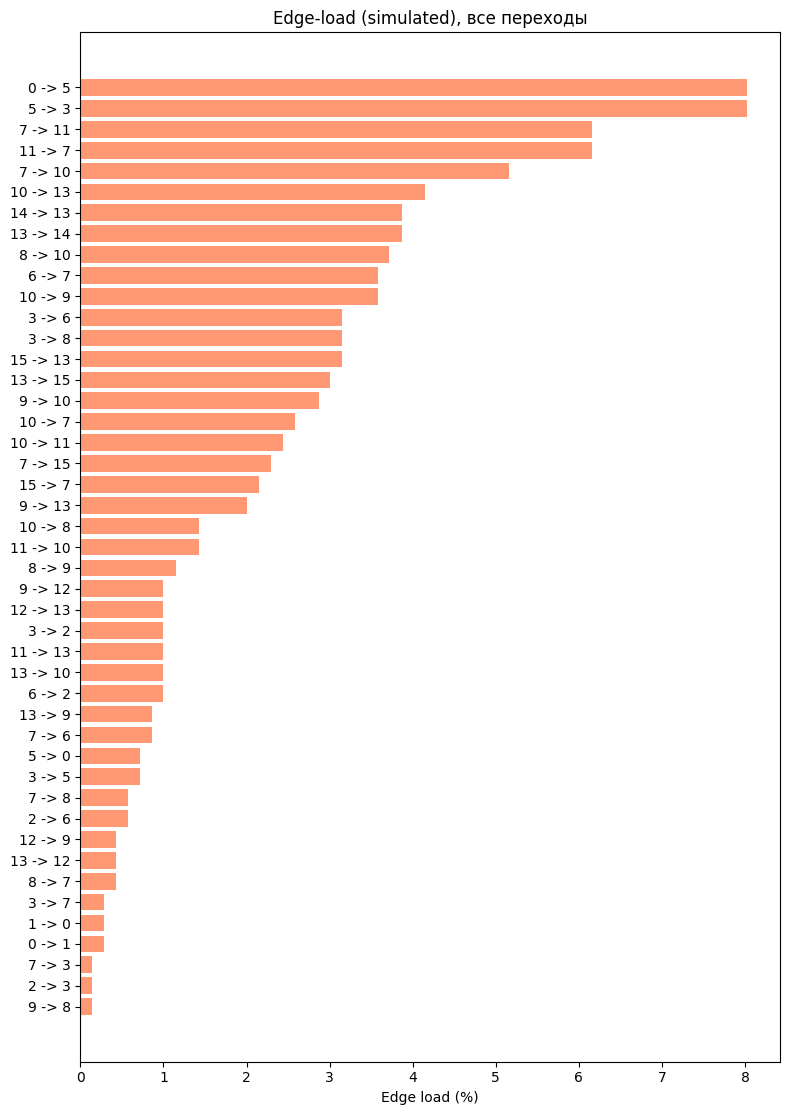

In [152]:
import pandas as pd
traj_sim = parse_trajectories_from_dxf(PATH_DXF, LAYER_SIMULATION)
total_sim, df_trans_sim = 0, pd.DataFrame()
if len(traj_sim) == 0:
    print("Слой Simulation пуст или отсутствует.")
else:
    df_trans_sim, total_sim = compute_transition_matrix(polygons_with_zone, zone_labels, traj_sim)
    print("Edge-load (simulated), total transitions:", total_sim)
    print("n_edges (уникальных переходов):", len(df_trans_sim))
    print("dependency_pct: min={:.2f}, max={:.2f}, mean={:.2f}, median={:.2f}, std={:.2f}".format(
        df_trans_sim["dependency_pct"].min(), df_trans_sim["dependency_pct"].max(),
        df_trans_sim["dependency_pct"].mean(), df_trans_sim["dependency_pct"].median(),
        df_trans_sim["dependency_pct"].std()))
    print("count: min={}, max={}, mean={:.2f}, median={:.2f}, std={:.2f}".format(
        df_trans_sim["count"].min(), df_trans_sim["count"].max(),
        df_trans_sim["count"].mean(), df_trans_sim["count"].median(),
        df_trans_sim["count"].std()))
    display(df_trans_sim)
    df_plot = df_trans_sim.sort_values("dependency_pct", ascending=True)
    df_plot["edge"] = df_plot["from_zone"].astype(str) + " -> " + df_plot["to_zone"].astype(str)
    plt.figure(figsize=(8, max(8, len(df_plot) * 0.25)))
    plt.barh(df_plot["edge"], df_plot["dependency_pct"], color="coral", alpha=0.8)
    plt.xlabel("Edge load (%)")
    plt.title("Edge-load (simulated), все переходы")
    plt.tight_layout()
    plt.show()

## Сравнение edge-load

Scatter: dependency_pct real vs simulated по переходам. Близость к диагонали y=x — похожий паттерн.

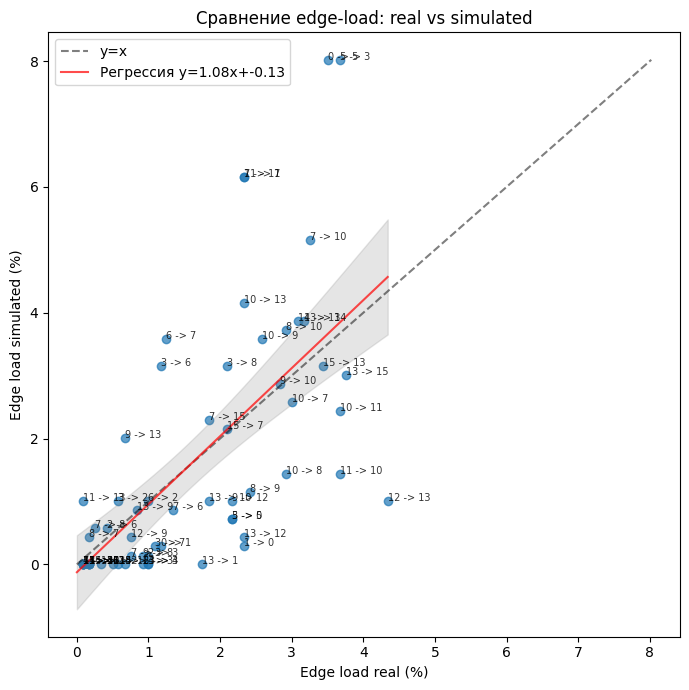

--- Базовая статистика edge-load ---
pct_real:  mean=1.5382, std=1.2288, min=0.0800, max=4.3400
pct_sim:   mean=1.5382, std=1.9731, min=0.0000, max=8.0200
count_real: mean=18.42, std=14.70, min=1, max=52
count_sim:  mean=10.74, std=13.77, min=0, max=56
--- Корреляция и метрики сравнения edge-load ---
dependency_pct: Pearson=0.6735, Spearman=0.7799
dependency_pct: MAE=1.0095, RMSE=1.4619
count: Pearson=0.6731, Spearman=0.7799
count: MAE=10.42


In [153]:
# Fallback: загрузить симуляцию из DXF, если не запущена
try:
    from room_popularity import parse_trajectories_from_dxf, parse_zones_from_dxf, compute_transition_matrix
except ImportError:
    pass
if "traj_sim" not in globals() or len(traj_sim) == 0:
    traj_sim = parse_trajectories_from_dxf(PATH_DXF, LAYER_SIMULATION)
if "polygons_with_zone" not in globals() or "zone_labels" not in globals():
    polygons_with_zone, zone_labels = parse_zones_from_dxf(PATH_DXF, LAYER_AREA)
if len(traj_sim) > 0 and ("df_trans_sim" not in globals() or "total_sim" not in globals()):
    df_trans_sim, total_sim = compute_transition_matrix(polygons_with_zone, zone_labels, traj_sim)

if len(traj_sim) > 0 and total_sim > 0:
    merge_df = df_trans_real.rename(columns={"dependency_pct": "pct_real", "count": "count_real"})
    merge_df = merge_df.merge(
        df_trans_sim[["from_zone", "to_zone", "dependency_pct", "count"]].rename(
            columns={"dependency_pct": "pct_sim", "count": "count_sim"}
        ),
        on=["from_zone", "to_zone"], how="outer"
    ).fillna(0)
    merge_df["edge"] = merge_df["from_zone"].astype(int).astype(str) + " -> " + merge_df["to_zone"].astype(int).astype(str)
    plt.figure(figsize=(7, 7))
    plt.scatter(merge_df["pct_real"], merge_df["pct_sim"], alpha=0.7)
    for _, r in merge_df.iterrows():
        plt.annotate(r["edge"], (r["pct_real"], r["pct_sim"]), fontsize=7, alpha=0.8)
    plt.xlabel("Edge load real (%)")
    plt.ylabel("Edge load simulated (%)")
    plt.title("Сравнение edge-load: real vs simulated")
    mx = merge_df[["pct_real", "pct_sim"]].max().max()
    plt.plot([0, mx], [0, mx], "k--", alpha=0.5, label="y=x")
    b, a = np.polyfit(merge_df["pct_real"], merge_df["pct_sim"], 1)
    x_line = np.linspace(0, merge_df["pct_real"].max(), 100)
    y_line = a + b * x_line
    if len(merge_df) >= 3:
        from scipy.stats import t as t_dist
        x_vals, y_vals = merge_df["pct_real"].values, merge_df["pct_sim"].values
        n = len(x_vals)
        y_pred = a + b * x_vals
        mse = np.sum((y_vals - y_pred)**2) / (n - 2)
        x_mean = np.mean(x_vals)
        ss_x = np.sum((x_vals - x_mean)**2)
        se = np.sqrt(mse * (1/n + (x_line - x_mean)**2 / ss_x))
        t_val = t_dist.ppf(0.975, n - 2)
        plt.fill_between(x_line, y_line - t_val * se, y_line + t_val * se, alpha=0.2, color="gray")
    plt.plot(x_line, y_line, "r-", alpha=0.7, label=f"Регрессия y={b:.2f}x+{a:.2f}")
    plt.legend()
    plt.tight_layout()
    plt.show()
    # Корреляция и метрики сравнения
    from scipy import stats
    import numpy as np
    pct_real = merge_df["pct_real"].values
    pct_sim = merge_df["pct_sim"].values
    count_real = merge_df["count_real"].values
    count_sim = merge_df["count_sim"].values
    pearson_pct, _ = stats.pearsonr(pct_real, pct_sim)
    spearman_pct, _ = stats.spearmanr(pct_real, pct_sim)
    pearson_cnt, _ = stats.pearsonr(count_real, count_sim)
    spearman_cnt, _ = stats.spearmanr(count_real, count_sim)
    mae_pct = np.mean(np.abs(pct_real - pct_sim))
    rmse_pct = np.sqrt(np.mean((pct_real - pct_sim) ** 2))
    mae_cnt = np.mean(np.abs(count_real - count_sim))
    print("--- Базовая статистика edge-load ---")
    print(f"pct_real:  mean={np.mean(pct_real):.4f}, std={np.std(pct_real):.4f}, min={np.min(pct_real):.4f}, max={np.max(pct_real):.4f}")
    print(f"pct_sim:   mean={np.mean(pct_sim):.4f}, std={np.std(pct_sim):.4f}, min={np.min(pct_sim):.4f}, max={np.max(pct_sim):.4f}")
    print(f"count_real: mean={np.mean(count_real):.2f}, std={np.std(count_real):.2f}, min={np.min(count_real):.0f}, max={np.max(count_real):.0f}")
    print(f"count_sim:  mean={np.mean(count_sim):.2f}, std={np.std(count_sim):.2f}, min={np.min(count_sim):.0f}, max={np.max(count_sim):.0f}")
    print("--- Корреляция и метрики сравнения edge-load ---")
    print(f"dependency_pct: Pearson={pearson_pct:.4f}, Spearman={spearman_pct:.4f}")
    print(f"dependency_pct: MAE={mae_pct:.4f}, RMSE={rmse_pct:.4f}")
    print(f"count: Pearson={pearson_cnt:.4f}, Spearman={spearman_cnt:.4f}")
    print(f"count: MAE={mae_cnt:.2f}")
else:
    print("Нет симулированных треков для сравнения edge-load.")